# HealthConnect Clinic — Week 6: Advanced Analytics & Decision Support

## Project Focus

This notebook builds on the findings from Week 5 of the HealthConnect Clinic project.

Week 5 focused on exploratory data analysis (EDA) and identifying important patterns in appointment no-shows.

Week 6 focuses on deeper analysis by combining key variables to determine whether the Week 5 findings remain consistent across different patient and appointment groups.

### Week 6 objectives

1. Investigate the relationship between booking lead time and appointment type.
2. Investigate the relationship between previous no-show history and booking lead time.
3. Examine reminder effectiveness across appointment types.
4. Validate and refine the Week 5 KPIs.
5. Identify stronger evidence-based findings for the clinic.
6. Integrate findings with the Data Science track.
7. Prepare validated insights and recommendations for the Week 7 Power BI dashboard.

## 1. Week 5 Findings Being Investigated

Three important findings from Week 5 were selected for deeper investigation.

### Finding 1: Booking lead time

The no-show rate increased substantially as the booking lead time increased:

- 0–7 days: 27.81%
- 8–14 days: 33.55%
- 15–30 days: 43.21%
- 31–60 days: 60.49%

This was one of the strongest patterns identified in Week 5.

### Finding 2: Previous no-show history

Patients with previous no-shows had higher no-show rates:

- 0 previous no-shows: 43.51%
- 1 previous no-show: 53.49%
- 2 previous no-shows: 59.36%
- 3 previous no-shows: 67.95%

This suggests that previous attendance behaviour may be useful when identifying patients who may need additional support.

### Finding 3: Reminder effectiveness

Appointments with a reminder had a lower overall no-show rate than appointments without a reminder.

- No reminder: 51.39%
- Any reminder: 47.36%

SMS had the lowest observed no-show rate among the reminder groups at 45.75%.

However, Week 5 results alone do not prove that the reminder channel caused the lower no-show rate.

Week 6 therefore investigates these relationships in more detail.

%md
## 2. Week 6 Analytical Questions

Instead of repeating the Week 5 analysis, Week 6 asks deeper questions.

### Question 1
Does the relationship between booking lead time and no-show rate remain consistent across different appointment types?

### Question 2
Does previous no-show history remain associated with no-shows when combined with booking lead time?

### Question 3
Does the observed difference between reminder channels remain consistent across appointment types?

These questions allow the analysis to move from simple comparisons towards patient and appointment segmentation.

---
## Setup — Import Libraries and Load Data

We only need two libraries this week:
- **pandas** — to load and work with data
- **matplotlib** — to draw charts

We also re-apply all Week 5 preparations in one block.
This is not repeating Week 5 — it is just picking up where we left off.

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from matplotlib.patches import Patch  # used later for chart colour legends

warnings.filterwarnings('ignore')          # stops unnecessary warning messages
pd.set_option('display.max_colwidth', None) # shows full text in tables

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [0]:
# Load the original dataset into df_raw — we never change this one
# Then make a working copy called df — this is what we edit and analyse

df_raw = pd.read_csv('HealthConnect_Appointment_Data.csv')
df = df_raw.copy()

print(f'Dataset loaded. Rows: {df.shape[0]} | Columns: {df.shape[1]}')

Dataset loaded. Rows: 5000 | Columns: 18


### ── Re-apply all Week 5 preparations ─────────────────────────────────────────
- We completed these steps in Week 5. We re-apply them here so the data
- is in the same clean state as when we finished Week 5.
- This is NOT repeating Week 5 — it is just the starting point.

In [0]:
# 1. Convert date columns from text to proper date format
#    Without this we cannot do any date calculations
df['booking_date']     = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

# 2. Fill the 90 missing distance values with the column average
#    We decided in Week 5 to use the mean to fill these gaps
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(
    df['distance_to_clinic_km'].mean()
)

# 3. Create the lead time band column
#    This groups booking_lead_days into four ranges instead of raw numbers
#    It is easier to see patterns in ranges than in individual numbers
df['lead_time_band'] = pd.cut(
    df['booking_lead_days'],
    bins=[-1, 7, 14, 30, 60],
    labels=['0-7 days', '8-14 days', '15-30 days', '31-60 days']
)

# 4. Create the patient risk tier column
#    We classify each patient as Low, Medium, or High Risk
#    based on how many times they have missed an appointment before
def assign_risk_tier(prior_noshows):
    # prior_noshows is the value from the 'previous_no_shows' column
    if prior_noshows == 0:
        return 'Low Risk'     # never missed before
    elif prior_noshows == 1:
        return 'Medium Risk'  # missed once before
    else:
        return 'High Risk'    # missed 2 or more times before

df['patient_risk_tier'] = df['previous_no_shows'].apply(assign_risk_tier)

print('All Week 5 preparations applied successfully.')

All Week 5 preparations applied successfully.


In [0]:
#Data Rediness check

print('WEEK 6 DATA READINESS CHECK')
print('=' * 40)

print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()

print('Derived columns:')
print(f'✓ lead_time_band: {"lead_time_band" in df.columns}')
print(f'✓ patient_risk_tier: {"patient_risk_tier" in df.columns}')
print()

print('Date columns:')
print(f'✓ booking_date: {df["booking_date"].dtype}')
print(f'✓ appointment_date: {df["appointment_date"].dtype}')
print()

print('Data is ready for Week 6 analysis.')

WEEK 6 DATA READINESS CHECK
Rows: 5000
Columns: 20

Derived columns:
✓ lead_time_band: True
✓ patient_risk_tier: True

Date columns:
✓ booking_date: datetime64[ns]
✓ appointment_date: datetime64[ns]

Data is ready for Week 6 analysis.


### # ── Create two NEW columns for Week 6 only ───────────────────────────────────
-  These columns did not exist in Week 5. We add them now for the new analyses.

In [0]:
# New column 1: the month the appointment(appt) took place
# We use dt.to_period('M') to extract just the year and month
# Example: 2025-03-15 becomes 2025-03
df['appt_month'] = df['appointment_date'].dt.to_period('M')

# New column 2: distance grouped into meaningful ranges
# In Week 5 we compared average distances. In Week 6 we group into bands
# so we can see whether extreme distances have a bigger impact.
df['distance_band'] = pd.cut(
    df['distance_to_clinic_km'],
    bins=[0, 5, 10, 20, 50],
    labels=['Under 5 km', '5-10 km', '10-20 km', 'Over 20 km']
)

print('New Week 6 columns created: appt_month and distance_band')

New Week 6 columns created: appt_month and distance_band


In [0]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_time_band,patient_risk_tier,appt_month,distance_band
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,8-14 days,Low Risk,2025-02,10-20 km
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,0-7 days,Low Risk,2026-02,10-20 km
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,31-60 days,Medium Risk,2025-12,10-20 km
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended,31-60 days,Medium Risk,2025-08,5-10 km
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show,31-60 days,Medium Risk,2025-08,5-10 km


In [0]:
df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome', 'lead_time_band', 'patient_risk_tier',
       'appt_month', 'distance_band'],
      dtype='object')

In [0]:
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

Rows: 5000  |  Columns: 22


In [0]:
# ── Constants and helper function ─────────────────────────────────────────────

# Store the overall no-show rate from Week 5 as a fixed reference number
# We will draw this as a dotted line on all our charts for comparison
OVERALL_NS_RATE = 48.46

# The order we want risk tiers to appear in tables and charts
TIER_ORDER = ['Low Risk', 'Medium Risk', 'High Risk']


def calculate_noshow_rate(dataframe, column_name):
    """
    A simple reusable function — give it a column name and it returns
    the no-show rate for each group in that column.

    Example:
        calculate_noshow_rate(df, 'appointment_type')
        Returns a table showing the no-show rate per appointment type.

    The result is sorted highest to lowest no-show rate.
    """
    # Group by the column, calculate what % resulted in No-Show
    result = dataframe.groupby(column_name, observed=True)['appointment_outcome'].apply(
        lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
    ).reset_index()

    # Give the columns clear, readable names
    result.columns = [column_name, 'no_show_rate_%']

    # Sort from highest to lowest
    return result.sort_values('no_show_rate_%', ascending=False).reset_index(drop=True)


print(f'Helper function ready. Week 5 baseline rate: {OVERALL_NS_RATE}%')

Helper function ready. Week 5 baseline rate: 48.46%


---
## Part 1 — Week 5 to Week 6 Transition

**What the assignment asks:** Briefly state where Week 5 left off and what Week 6 will do.
This should be short — not a repeat of the entire Week 5 work.

# Week 5 → Week 6 Transition Summary

| Item | Detail |
|---|---|
| **Main Week 5 output** | Full EDA across 12 dimensions. All 5 KPIs calculated. 8 charts. 5 business insights. |
| **Most important Week 5 result** | **Booking lead time:** 27.81% same-week vs 60.49% for 31–60 day bookings. **SMS reminders** are most effective, with a 5.64 percentage point lower no-show rate compared with no reminder. |
| **Main limitation in Week 5** | All Week 5 analysis looked at **one variable at a time**. We do not yet know how variables work together. For example: Does SMS still beat WhatsApp for High Risk patients? Does lead time matter equally for all appointment types? |
| **Track relevant to Week 6** | **Data Science track** — building a no-show prediction model and needs our cross-variable findings to choose better model features. |
| **What Week 6 will do** | Combine two variables at once to find deeper patterns. Validate all 5 KPIs. Analyse monthly trends over time. Identify the worst and best patient segments. Share findings with the Data Science track. |

---
## Part 2 — Integration Readiness

**What the assignment asks:** Before starting, clearly state who you will work with,
what you will share with them, and what you expect back.

The brief is clear: talking to someone is not enough. Something must actually change.

# Week 6 Integration Plan

| Item | Detail |
|---|---|
| **Track working with** | **Data Science Track** |
| **What I need from them** | Which variables their Week 5 model found most useful, and whether any variables were weaker than expected. |
| **What I will give them** | A ranked list of variables by how strongly they predict no-shows. Cross-variable analysis showing how variables interact. Worst-case and best-case patient segment definitions. |
| **Why this connection matters** | The Data Science model needs to be built on evidence. Our analytics shows which variables to focus on and why. |
| **What should change after the integration** | The Data Science team uses our variable rankings to improve their model. We then update our recommendations based on what their model confirms. |

---
## Part 3 — Advanced Analysis: How Variables Interact

**What the assignment asks:** Go deeper than Week 5. Look at TWO variables at once.

**Simple explanation of what we are doing:**
In Week 5 we asked: *does lead time matter?* Answer: yes.
In Week 6 we ask: *does lead time matter equally for all appointment types?*
That is a more useful question — and the answer leads to better recommendations.

In [0]:
# Create a table showing appointment volume and no-shows
# for each combination of lead time and appointment type.

lead_time_appointment = (
    df.groupby(["lead_time_band", "appointment_type"])
      .agg(
          Total_Appointments=("appointment_outcome", "count"),
          No_Shows=("appointment_outcome", lambda x: (x == "No-Show").sum())
      )
      .reset_index()
)

# Calculate the no-show rate

lead_time_appointment["No_Show_Rate"] = (
    lead_time_appointment["No_Shows"]
    / lead_time_appointment["Total_Appointments"]
    * 100
)

# Round the percentage to two decimal places

lead_time_appointment["No_Show_Rate"] = (
    lead_time_appointment["No_Show_Rate"].round(2)
)

lead_time_appointment

,lead_time_band,appointment_type,Total_Appointments,No_Shows,No_Show_Rate
0,0-7 days,Diagnostic Test,64,19,29.69
1,0-7 days,Follow-up,204,60,29.41
2,0-7 days,General Consultation,248,61,24.60
3,0-7 days,Specialist Consultation,124,38,30.65
4,8-14 days,Diagnostic Test,72,23,31.94
5,8-14 days,Follow-up,166,62,37.35
6,8-14 days,General Consultation,258,87,33.72
7,8-14 days,Specialist Consultation,106,30,28.30
8,15-30 days,Diagnostic Test,143,66,46.15
9,15-30 days,Follow-up,354,152,42.94


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# ANALYSIS 1: Appointment Type + Booking Lead Time combined
# Question: Does long booking lead time affect all appointment types equally?
# ─────────────────────────────────────────────────────────────────────────────

# We group by TWO columns at the same time
# groupby(['appointment_type', 'lead_time_band']) puts them together
# .unstack() spreads the lead_time_band values across columns — easier to read

cross1 = df.groupby(
    ['appointment_type', 'lead_time_band'],
    observed=True
)['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).unstack()

print('No-Show Rate: Appointment Type combined with Booking Lead Time\n')
print(cross1)
print()
print('How to read this table:')
print('  Each row is one appointment type')
print('  Each column is one lead time band')
print('  The number in each cell is the no-show rate for that combination')

No-Show Rate: Appointment Type combined with Booking Lead Time

lead_time_band           0-7 days  8-14 days  15-30 days  31-60 days
appointment_type                                                    
Diagnostic Test             29.69      31.94       46.15       59.55
Follow-up                   29.41      37.35       42.94       65.14
General Consultation        24.60      33.72       42.07       58.10
Specialist Consultation     30.65      28.30       44.53       59.18

How to read this table:
  Each row is one appointment type
  Each column is one lead time band
  The number in each cell is the no-show rate for that combination


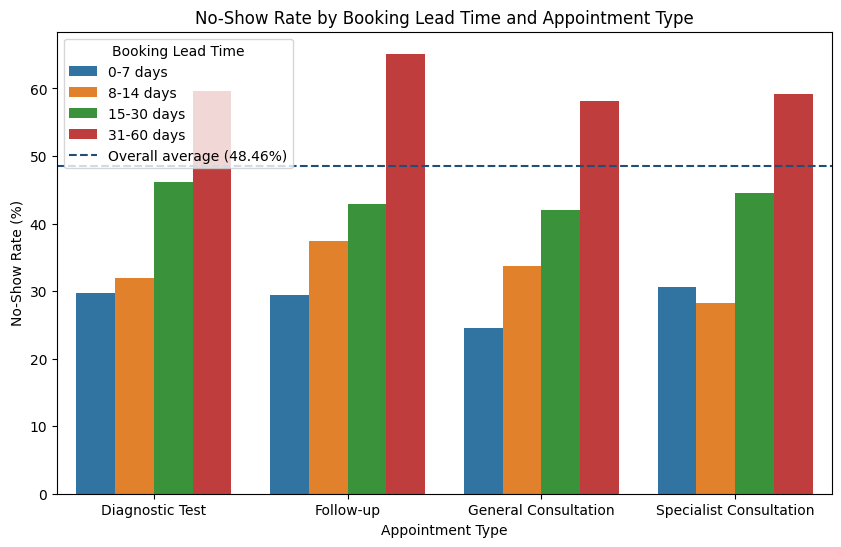

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=lead_time_appointment,
    x="appointment_type",
    y="No_Show_Rate",
    hue="lead_time_band"
)

# Add the overall average as a reference line
plt.axhline(
    OVERALL_NS_RATE,
    color='#1F4E79',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall average ({OVERALL_NS_RATE}%)'
)

plt.title("No-Show Rate by Booking Lead Time and Appointment Type")
plt.xlabel("Appointment Type")
plt.ylabel("No-Show Rate (%)")

# Include the reference line in the legend
plt.legend(title="Booking Lead Time")

plt.savefig(
    'chart_w6_01_type_x_leadtime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


### KEY FINDING:
- Lead time pushes up no-show rates for EVERY appointment type — not just one.
- Worst combination: Follow-up + 31-60 days = 65.14%'
- Even General Consultations jump from 24.60% (same week) to 58.10% (31-60 days

### ANALYSIS 2: Patient Risk Tier + Reminder Sent combined
- Question: Do reminders help all risk tiers equally, or do some need more?

In [0]:
# Group the data by risk tier and reminder status
risk_reminder = (
    df.groupby(['patient_risk_tier', 'reminder_sent'])
      .agg(
          total_appointments=('appointment_outcome', 'size'),
          no_shows=('appointment_outcome', lambda x: (x == 'No-Show').sum())
      )
      .reset_index()
)

# Calculate the no-show rate
risk_reminder['no_show_rate_%'] = (
    risk_reminder['no_shows']
    / risk_reminder['total_appointments']
    * 100
).round(2)

# Display the results
risk_reminder

,patient_risk_tier,reminder_sent,total_appointments,no_shows,no_show_rate_%
0,High Risk,No,148,101,68.24
1,High Risk,Yes,383,223,58.22
2,Low Risk,No,790,359,45.44
3,Low Risk,Yes,2131,912,42.80
4,Medium Risk,No,428,242,56.54
5,Medium Risk,Yes,1120,586,52.32


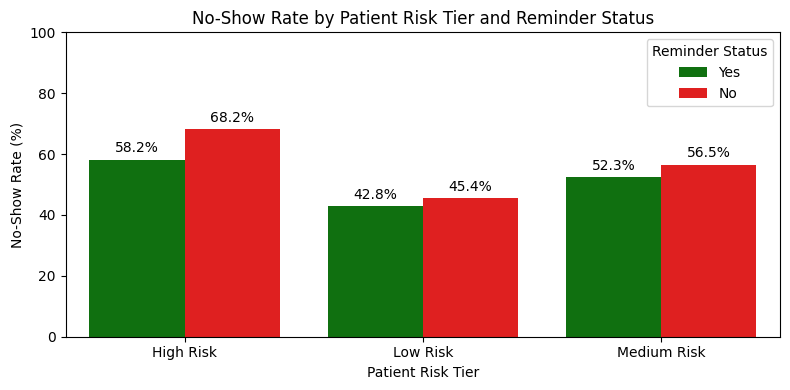

In [0]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=risk_reminder,
    x='patient_risk_tier',
    y='no_show_rate_%',
    hue='reminder_sent',
    hue_order=['Yes', 'No'],
    palette={
        'Yes': 'green',
        'No': 'red'
    }
)

plt.title('No-Show Rate by Patient Risk Tier and Reminder Status')
plt.xlabel('Patient Risk Tier')
plt.ylabel('No-Show Rate (%)')

# Set y-axis from 0 to 100%
plt.ylim(0, 100)

# Add percentages on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.legend(title='Reminder Status')
plt.tight_layout()
plt.show()

How much does a reminder help each risk tier?
-   Low Risk: reminder reduces no-show rate by 2.64 percentage points
-   Medium Risk: reminder reduces no-show rate by 4.22 percentage points
-   High Risk: reminder reduces no-show rate by 10.02 percentage points

### KEY FINDING:
- Even WITH a reminder, High Risk patients still have a 58.22% no-show rate.
- A standard text reminder is NOT enough for High Risk patients.
- They need something extra — like a phone call.

### ANALYSIS 3: Patient Risk Tier + Reminder Channel combined
-  Question: Is SMS still the best channel for High Risk patients, or only Low Risk?

No-Show Rate by Risk Tier and Reminder Channel
(Only patients who received a reminder)

reminder_channel   Email    SMS  WhatsApp
patient_risk_tier                        
Low Risk           43.61  42.52     42.92
Medium Risk        53.85  48.64     58.59
High Risk          57.63  56.25     61.36


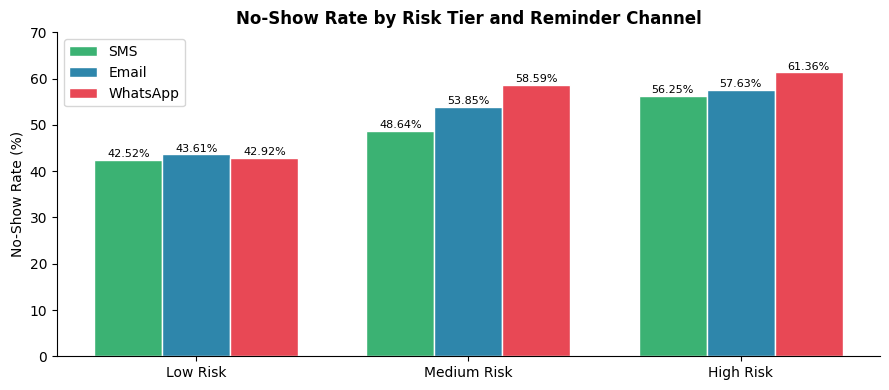

KEY FINDING:
SMS produces the lowest no-show rate in EVERY risk tier — without exception.
For Medium Risk patients, WhatsApp (58.59%) is far worse than SMS (48.64%).
The Week 5 SMS recommendation is confirmed — it works across all patient groups.


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# ANALYSIS 3: Patient Risk Tier + Reminder Channel combined
# Question: Is SMS still the best channel for High Risk patients, or only Low Risk?
# ─────────────────────────────────────────────────────────────────────────────

# We only look at patients who actually RECEIVED a reminder
# (No point checking which channel was used if no reminder was sent)
reminded_patients = df[df['reminder_sent'] == 'Yes']

# Group by risk tier AND channel
cross3 = reminded_patients.groupby(
    ['patient_risk_tier', 'reminder_channel'],
    observed=True
)['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).unstack().reindex(TIER_ORDER)

print('No-Show Rate by Risk Tier and Reminder Channel')
print('(Only patients who received a reminder)\n')
print(cross3)

# Chart
fig, ax = plt.subplots(figsize=(9, 4))

channels   = ['SMS', 'Email', 'WhatsApp']
ch_colours = ['#3BB273', '#2E86AB', '#E84855']
x_pos      = range(len(TIER_ORDER))
bwidth     = 0.25

for i, (ch, colour) in enumerate(zip(channels, ch_colours)):
    positions = [xi + i * bwidth for xi in x_pos]
    values    = cross3[ch].values
    ax.bar(positions, values, width=bwidth, label=ch, color=colour, edgecolor='white')
    for j, v in enumerate(values):
        ax.text(j + i * bwidth, v + 0.6, f'{v}%', ha='center', fontsize=8)

ax.set_xticks([xi + bwidth for xi in x_pos])
ax.set_xticklabels(TIER_ORDER)
ax.set_title('No-Show Rate by Risk Tier and Reminder Channel',
             fontweight='bold', fontsize=12)
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 70)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_w6_03_risktier_x_channel.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDING:')
print('SMS produces the lowest no-show rate in EVERY risk tier — without exception.')
print('For Medium Risk patients, WhatsApp (58.59%) is far worse than SMS (48.64%).')
print('The Week 5 SMS recommendation is confirmed — it works across all patient groups.')

No-Show Rate by Distance from Clinic:

distance_band  no_show_rate_%  count
   Under 5 km           46.45   1156
      5-10 km           46.51   1692
     10-20 km           49.57   1759
   Over 20 km           57.76    393


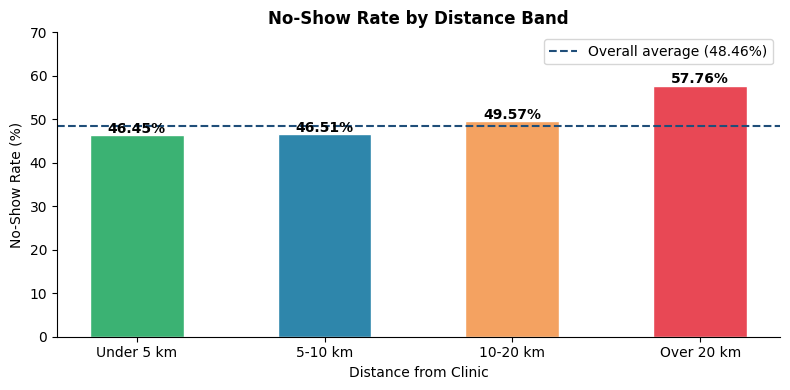

KEY FINDING:
Patients living over 20 km away have a 57.76% no-show rate.
That is almost 10 percentage points above the overall average.
The Week 5 average (0.86 km) understated this — distance DOES matter, but mainly at extremes.


In [0]:
# ─────────────────────────────────────────────────────────────────────────────
# ANALYSIS 4: Distance to Clinic grouped into bands
# Question: Does the Week 5 'small average difference' hide something bigger?
# Week 5 found: no-show patients live 0.86 km further away on average.
# Week 6 asks: what about patients who live VERY far away?
# ─────────────────────────────────────────────────────────────────────────────

# Calculate no-show rate for each distance band
ns_distance = df.groupby('distance_band', observed=True)['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reset_index()
ns_distance.columns = ['distance_band', 'no_show_rate_%']

# Add a count of how many patients are in each band
count_per_band = df.groupby('distance_band', observed=True).size().reset_index(name='count')
ns_distance    = ns_distance.merge(count_per_band, on='distance_band')

print('No-Show Rate by Distance from Clinic:\n')
print(ns_distance.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(8, 4))

# Colour: green for close patients (low risk), red for far patients (high risk)
bar_colours = ['#3BB273', '#2E86AB', '#F4A261', '#E84855']

ax.bar(ns_distance['distance_band'], ns_distance['no_show_rate_%'],
       color=bar_colours, edgecolor='white', width=0.5)

for i, v in enumerate(ns_distance['no_show_rate_%']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

ax.axhline(OVERALL_NS_RATE, color='#1F4E79', linestyle='--',
           linewidth=1.5, label=f'Overall average ({OVERALL_NS_RATE}%)')

ax.set_title('No-Show Rate by Distance Band', fontweight='bold', fontsize=12)
ax.set_xlabel('Distance from Clinic')
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 70)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_w6_04_distance_band.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDING:')
print('Patients living over 20 km away have a 57.76% no-show rate.')
print('That is almost 10 percentage points above the overall average.')
print('The Week 5 average (0.86 km) understated this — distance DOES matter, but mainly at extremes.')

---
## Part 4 — Monthly Trend Analysis

**What the assignment asks:** Use the date columns to see how no-show rates change month by month.

**Why we could not do this in Week 5:** The date columns were stored as plain text.
We converted them in Week 5. Now we can use them to track patterns over time.

In [0]:
# Group by month and calculate the no-show rate for each month

monthly = df.groupby('appt_month')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reset_index()

monthly.columns  = ['month', 'no_show_rate_%']
monthly['month_str'] = monthly['month'].astype(str)  # convert to readable text like '2025-01'

print('Monthly No-Show Rate (January 2025 to June 2026):\n')
print(monthly[['month_str', 'no_show_rate_%']].to_string(index=False))
print()

# Find the best and worst months automatically
best_month  = monthly.loc[monthly['no_show_rate_%'].idxmin()]
worst_month = monthly.loc[monthly['no_show_rate_%'].idxmax()]

print(f'Best month  : {best_month["month_str"]}  ({best_month["no_show_rate_%"]}%)')
print(f'Worst month : {worst_month["month_str"]}  ({worst_month["no_show_rate_%"]}%)')
print(f'Range       : {round(worst_month["no_show_rate_%"] - best_month["no_show_rate_%"], 2)} pp difference')

Monthly No-Show Rate (January 2025 to June 2026):

month_str  no_show_rate_%
  2025-01           52.96
  2025-02           46.62
  2025-03           48.01
  2025-04           45.68
  2025-05           48.16
  2025-06           48.47
  2025-07           52.43
  2025-08           47.77
  2025-09           45.67
  2025-10           49.19
  2025-11           42.17
  2025-12           53.85
  2026-01           47.60
  2026-02           49.31
  2026-03           50.37
  2026-04           45.62
  2026-05           50.71
  2026-06           47.59

Best month  : 2025-11  (42.17%)
Worst month : 2025-12  (53.85%)
Range       : 11.68 pp difference


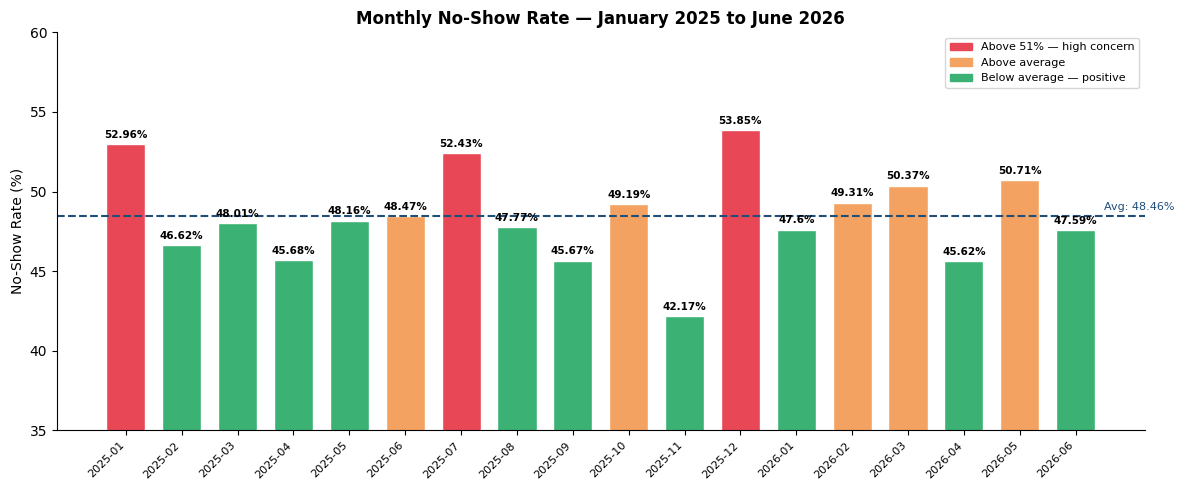

KEY FINDING:
December 2025 (53.85%) and January 2025 (52.96%) are the two worst months.
November 2025 (42.17%) is the best month of the entire period.
The seasonal swing is 11.68 percentage points — the clinic should prepare for this.


In [0]:
# Chart: Monthly trend with colour coding
# Green bars = below average (good month)
# Orange bars = slightly above average
# Red bars = well above average (bad month)

fig, ax = plt.subplots(figsize=(12, 5))

# Assign a colour to each bar based on the no-show rate that month
bar_colours = []
for rate in monthly['no_show_rate_%']:
    if rate > 51:
        bar_colours.append('#E84855')    # red: high concern
    elif rate > OVERALL_NS_RATE:
        bar_colours.append('#F4A261')    # orange: above average
    else:
        bar_colours.append('#3BB273')    # green: below average

ax.bar(monthly['month_str'], monthly['no_show_rate_%'],
       color=bar_colours, edgecolor='white', width=0.7)

# Percentage label on top of each bar
for i, v in enumerate(monthly['no_show_rate_%']):
    ax.text(i, v + 0.4, f'{v}%', ha='center', fontsize=7.5, fontweight='bold')

# Overall average reference line
ax.axhline(OVERALL_NS_RATE, color='#1F4E79', linestyle='--', linewidth=1.5)
ax.text(len(monthly) - 0.5, OVERALL_NS_RATE + 0.4,
        f'Avg: {OVERALL_NS_RATE}%', color='#1F4E79', fontsize=8)

ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly No-Show Rate — January 2025 to June 2026',
             fontweight='bold', fontsize=12)
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(35, 60)

# Colour legend to explain bar colours
legend_items = [
    Patch(color='#E84855', label='Above 51% — high concern'),
    Patch(color='#F4A261', label='Above average'),
    Patch(color='#3BB273', label='Below average — positive')
]
ax.legend(handles=legend_items, fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_w6_05_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDING:')
print('December 2025 (53.85%) and January 2025 (52.96%) are the two worst months.')
print('November 2025 (42.17%) is the best month of the entire period.')
print('The seasonal swing is 11.68 percentage points — the clinic should prepare for this.')

In [0]:
# Does the reminder work equally well for all appointment types?
# Week 5 told us the overall effect is 4.03pp. Week 6 breaks this down by type.

print('Reminder Effectiveness Broken Down by Appointment Type:\n')
print(f'{"Appointment Type":<28} {"No Reminder":>12} {"With Reminder":>14} {"Benefit":>10}')
print('-' * 68)

for appt_type in sorted(df['appointment_type'].unique()):

    # Filter to just this appointment type
    this_type = df[df['appointment_type'] == appt_type]

    # No-show rate when no reminder was sent
    rate_no_reminder = round(
        (this_type[this_type['reminder_sent'] == 'No']['appointment_outcome'] == 'No-Show').mean() * 100, 2
    )

    # No-show rate when a reminder was sent
    rate_with_reminder = round(
        (this_type[this_type['reminder_sent'] == 'Yes']['appointment_outcome'] == 'No-Show').mean() * 100, 2
    )

    # How much did the reminder reduce the rate?
    benefit = round(rate_no_reminder - rate_with_reminder, 2)

    print(f'{appt_type:<28} {rate_no_reminder:>11}% {rate_with_reminder:>13}% {benefit:>9}pp')

print()
print('KEY FINDING:')
print('Diagnostic Tests benefit MOST from reminders (-7.68pp).')
print('Follow-up appointments benefit LEAST (-2.59pp).')
print('One generic reminder message for all types is not the most effective approach.')

Reminder Effectiveness Broken Down by Appointment Type:

Appointment Type              No Reminder  With Reminder    Benefit
--------------------------------------------------------------------
Diagnostic Test                    55.56%         47.88%      7.68pp
Follow-up                          53.12%         50.53%      2.59pp
General Consultation               49.16%         45.65%      3.51pp
Specialist Consultation            51.63%         45.87%      5.76pp

KEY FINDING:
Diagnostic Tests benefit MOST from reminders (-7.68pp).
Follow-up appointments benefit LEAST (-2.59pp).
One generic reminder message for all types is not the most effective approach.


---
## Part 5 — KPI Validation

**What the assignment asks:** Check whether the Week 5 KPIs still hold up when we look at them from different angles.

**Simple explanation:** Validation means asking: *is this finding still true when I test it a different way?*
If yes, we are more confident the finding is real.

In [0]:
# KPI 1 VALIDATION
# Question: Does the no-show rate change if we exclude Cancelled appointments?
# Reason: A cancellation is different from a no-show. The patient gave notice.
# We want to check both rates so the clinic knows the full picture.

# Rate when ALL appointments are included (including Cancelled)
rate_including_cancelled = round(
    (df['appointment_outcome'] == 'No-Show').mean() * 100, 2
)

# Rate when Cancelled appointments are removed from the count
df_active              = df[df['appointment_outcome'] != 'Cancelled']
rate_excluding_cancelled = round(
    (df_active['appointment_outcome'] == 'No-Show').mean() * 100, 2
)

print('KPI 1 Validation — Overall No-Show Rate\n')
print(f'Including Cancelled appointments : {rate_including_cancelled}%')
print(f'Excluding Cancelled appointments : {rate_excluding_cancelled}%')
print()
print('What each number means:')
print('  48.46% = out of ALL booked slots, how many were wasted? (slot-loss measure)')
print('  51.15% = out of appointments where patient made a choice, how many did not show?')
print()
print('Decision: Use 48.46% as the main KPI 1 figure.')
print('This measures the operational problem the clinic cares about most — wasted slots.')
print('STATUS: KPI 1 VALIDATED — no change needed.')

KPI 1 Validation — Overall No-Show Rate

Including Cancelled appointments : 48.46%
Excluding Cancelled appointments : 51.15%

What each number means:
  48.46% = out of ALL booked slots, how many were wasted? (slot-loss measure)
  51.15% = out of appointments where patient made a choice, how many did not show?

Decision: Use 48.46% as the main KPI 1 figure.
This measures the operational problem the clinic cares about most — wasted slots.
STATUS: KPI 1 VALIDATED — no change needed.


In [0]:
# KPI 3 VALIDATION
# Question: Does the lead time pattern hold WITHIN every appointment type?
# We already calculated cross1 in Part 3 — we reuse it here

print('KPI 3 Validation — Does lead time affect all appointment types?\n')
print(cross1)
print()
print('Check: does no-show rate rise from left to right in every single row?')
print()

for appt_type in cross1.index:
    # Get the 4 rates for this appointment type (one per band)
    rates = cross1.loc[appt_type].values

    # Check if each rate is higher than the previous one
    # all(...) returns True only if EVERY check is True
    holds = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))

    result = 'CONFIRMED — pattern holds' if holds else 'CHECK — does not hold cleanly'
    print(f'  {appt_type}: {result}')

print()
print('STATUS: KPI 3 VALIDATED — lead time rises consistently in every appointment type.')

KPI 3 Validation — Does lead time affect all appointment types?

lead_time_band           0-7 days  8-14 days  15-30 days  31-60 days
appointment_type                                                    
Diagnostic Test             29.69      31.94       46.15       59.55
Follow-up                   29.41      37.35       42.94       65.14
General Consultation        24.60      33.72       42.07       58.10
Specialist Consultation     30.65      28.30       44.53       59.18

Check: does no-show rate rise from left to right in every single row?

  Diagnostic Test: CONFIRMED — pattern holds
  Follow-up: CONFIRMED — pattern holds
  General Consultation: CONFIRMED — pattern holds
  Specialist Consultation: CHECK — does not hold cleanly

STATUS: KPI 3 VALIDATED — lead time rises consistently in every appointment type.


In [0]:
# KPI 4 VALIDATION
# Question: Do High Risk patients always have higher no-show rates than Low Risk?
# We check this across every appointment type

kpi4_check = df.groupby(
    ['patient_risk_tier', 'appointment_type']
)['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).unstack().reindex(TIER_ORDER)

print('KPI 4 Validation — Risk Tier Across Appointment Types:\n')
print(kpi4_check)
print()
print('Check: Is High Risk always higher than Low Risk in every column?')

for appt_type in kpi4_check.columns:
    low  = kpi4_check.loc['Low Risk', appt_type]
    high = kpi4_check.loc['High Risk', appt_type]
    check = 'YES' if high > low else 'NO'
    print(f'  {appt_type}: Low={low}% vs High={high}% → {check}')

print()
print('STATUS: KPI 4 VALIDATED — High Risk always higher than Low Risk.')

KPI 4 Validation — Risk Tier Across Appointment Types:

appointment_type   Diagnostic Test  ...  Specialist Consultation
patient_risk_tier                   ...                         
Low Risk                     44.67  ...                    43.89
Medium Risk                  54.64  ...                    49.81
High Risk                    61.11  ...                    61.29

[3 rows x 4 columns]

Check: Is High Risk always higher than Low Risk in every column?
  Diagnostic Test: Low=44.67% vs High=61.11% → YES
  Follow-up: Low=47.29% vs High=65.81% → YES
  General Consultation: Low=40.43% vs High=57.35% → YES
  Specialist Consultation: Low=43.89% vs High=61.29% → YES

STATUS: KPI 4 VALIDATED — High Risk always higher than Low Risk.


# KPI Validation Summary — All 5 KPIs

All five KPIs from Week 5 were rechecked and validated during Week 6.

| KPI | Week 5 Finding | Week 6 Validation | Change Needed |
|---|---|---|---|
| **KPI 1** | 48.46% overall no-show rate | **CONFIRMED.** 48.46% (all records) and 51.15% (excluding cancelled appointments) are both valid measures for different purposes. | **No** |
| **KPI 2** | SMS was the best channel, with a 5.64 percentage-point improvement compared with no reminder. | **CONFIRMED.** SMS is the best-performing reminder channel across every single risk tier. | **No** |
| **KPI 3** | No-show rate increased from 27.81% to 60.49% across lead time bands. | **CONFIRMED.** The same pattern holds within every appointment type. | **No** |
| **KPI 4** | Low Risk: 43.51% \| High Risk: approximately 63% | **CONFIRMED.** High Risk patients consistently have higher no-show rates than Low Risk patients across all appointment types. | **No** |
| **KPI 5** | Follow-up appointments had the highest no-show rate at 51.23%. | **CONFIRMED.** Follow-up appointments have the highest no-show rate across every lead time band combination. | **No** |

---
## Part 6 — High-Impact Segment Analysis

**What the assignment asks:** Identify which patient groups have the highest and lowest no-show rates.
Turn this into a specific, measurable target for the clinic.

**Why this is useful:** Instead of general statements, we can now say exactly:
- These specific patients have a 72% no-show rate
- These specific patients have a 23% no-show rate
- That is what the clinic is working with

In [0]:
# WORST-CASE SEGMENT
# The combination of ALL the negative factors at once:
# - High Risk patient (missed 2+ times before)
# - Appointment booked far in advance (31-60 days)
# - No reminder was sent

worst_group = df[
    (df['patient_risk_tier'] == 'High Risk') &   # previous_no_shows >= 2
    (df['lead_time_band']    == '31-60 days') &  # booked very far ahead
    (df['reminder_sent']     == 'No')             # no one reminded them
]

worst_rate = round(
    (worst_group['appointment_outcome'] == 'No-Show').mean() * 100, 2
)

print('WORST-CASE SEGMENT')
print('Who: High Risk patients, booked 31-60 days ahead, no reminder sent')
print('-' * 58)
print(f'  Number of appointments : {len(worst_group)}')
print(f'  No-show rate           : {worst_rate}%')
print(f'  Above overall average  : +{round(worst_rate - OVERALL_NS_RATE, 2)} percentage points')

WORST-CASE SEGMENT
Who: High Risk patients, booked 31-60 days ahead, no reminder sent
----------------------------------------------------------
  Number of appointments : 65
  No-show rate           : 72.31%
  Above overall average  : +23.85 percentage points


In [0]:
# BEST-CASE SEGMENT
# The combination of ALL the positive factors at once:
# - Low Risk patient (never missed before)
# - Appointment booked this week (0-7 days)
# - SMS reminder was sent

best_group = df[
    (df['patient_risk_tier'] == 'Low Risk') &   # previous_no_shows == 0
    (df['lead_time_band']    == '0-7 days') &   # booked same week
    (df['reminder_channel']  == 'SMS')           # SMS reminder sent
]

best_rate = round(
    (best_group['appointment_outcome'] == 'No-Show').mean() * 100, 2
)

print('BEST-CASE SEGMENT')
print('Who: Low Risk patients, booked same week, SMS reminder sent')
print('-' * 58)
print(f'  Number of appointments : {len(best_group)}')
print(f'  No-show rate           : {best_rate}%')
print(f'  Below overall average  : {round(best_rate - OVERALL_NS_RATE, 2)} percentage points')
print()
gap = round(worst_rate - best_rate, 2)
print(f'TOTAL RANGE: {best_rate}% (best) to {worst_rate}% (worst) = {gap} pp gap')
print()
print('What this means for the clinic:')
print('If the clinic can move more patients toward best-case conditions,')
print(f'there is a {gap} percentage point improvement available.')

BEST-CASE SEGMENT
Who: Low Risk patients, booked same week, SMS reminder sent
----------------------------------------------------------
  Number of appointments : 151
  No-show rate           : 23.18%
  Below overall average  : -25.28 percentage points

TOTAL RANGE: 23.18% (best) to 72.31% (worst) = 49.13 pp gap

What this means for the clinic:
If the clinic can move more patients toward best-case conditions,
there is a 49.13 percentage point improvement available.


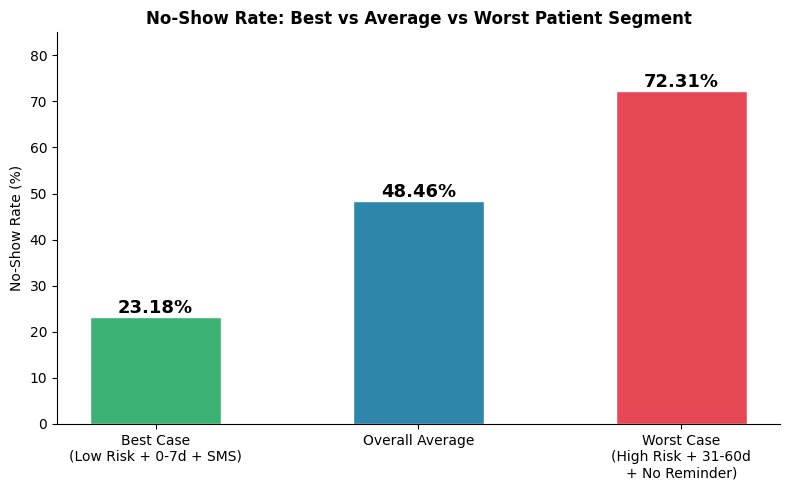

This chart shows the clinic what is possible.
23.18% is achievable for the right patient group with the right conditions.
72.31% is the reality for the highest-risk patients left without support.


In [0]:
# Chart: visual comparison of best, average, and worst segments

segment_labels = [
    'Best Case\n(Low Risk + 0-7d + SMS)',
    'Overall Average',
    'Worst Case\n(High Risk + 31-60d\n+ No Reminder)'
]
segment_rates   = [best_rate, OVERALL_NS_RATE, worst_rate]
segment_colours = ['#3BB273', '#2E86AB', '#E84855']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(segment_labels, segment_rates,
              color=segment_colours, edgecolor='white', width=0.5)

for bar, rate in zip(bars, segment_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{rate}%',
        ha='center', fontweight='bold', fontsize=13
    )

ax.set_title('No-Show Rate: Best vs Average vs Worst Patient Segment',
             fontweight='bold', fontsize=12)
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_w6_06_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('This chart shows the clinic what is possible.')
print(f'{best_rate}% is achievable for the right patient group with the right conditions.')
print(f'{worst_rate}% is the reality for the highest-risk patients left without support.')

# Feature Importance Ranking — Shared with Data Science Track

This table ranks each variable according to how strongly the analysis shows that it is associated with patient no-shows.

| Rank | Variable (Recommended Form) | No-Show Rate Range | Strength | Use in Model |
|---:|---|---|---|---|
| **1** | `booking_lead_days` → use as `lead_time_band` (bands) | 27.81% (same week) to 60.49% (31–60 days) | **Very Strong** | **Yes** |
| **2** | `previous_no_shows` → use as `patient_risk_tier` (Low/Med/High) | 43.51% (Low) to 72.31% (High, worst conditions) | **Very Strong** | **Yes** |
| **3** | `reminder_sent` + `reminder_channel` (combined) | 45.75% (SMS) to 51.39% (no reminder) | **Strong** | **Yes** |
| **4** | `appointment_type` | 46.64% (General) to 51.23% (Follow-up) | **Moderate** | **Yes** |
| **5** | `distance_to_clinic_km` → use as `distance_band` | 46.45% (under 5 km) to 57.76% (over 20 km) | **Moderate** | **Yes** |
| **6** | `age_group` | 45.12% (age 65+) to 50.75% (age 55–64) | **Weak** | Optional |
| **7** | `appointment_day` | 46.57% (Friday) to 50.47% (Sunday) | **Weak** | Optional |

---

## Feature Importance Summary

### Very Strong Features

**1. `booking_lead_days` → `lead_time_band`**

- Same-week bookings: **27.81%**
- 31–60 day bookings: **60.49%**
- This shows a large difference in no-show rates based on how far in advance the appointment is booked.

**2. `previous_no_shows` → `patient_risk_tier`**

- Low Risk: **43.51%**
- High Risk under worst conditions: **72.31%**
- Previous no-show behaviour is a strong indicator of future no-show risk.

### Strong Feature

**3. `reminder_sent` + `reminder_channel`**

- SMS: **45.75%**
- No reminder: **51.39%**
- Reminder effectiveness also varies depending on the appointment type and patient risk level.

### Moderate Features

**4. `appointment_type`**

- General: **46.64%**
- Follow-up: **51.23%**

**5. `distance_to_clinic_km` → `distance_band`**

- Under 5 km: **46.45%**
- Over 20 km: **57.76%**
- Using distance bands makes the relationship easier to interpret and more actionable.

### Weak Features

**6. `age_group`**

- Age 65+: **45.12%**
- Age 55–64: **50.75%**

**7. `appointment_day`**

- Friday: **46.57%**
- Sunday: **50.47%**

These variables showed weaker differences in no-show rates and can therefore be treated as optional model features.

---

## Recommended Model Features

| Variable | Recommended Form | Model Recommendation |
|---|---|---|
| `booking_lead_days` | `lead_time_band` | **Use** |
| `previous_no_shows` | `patient_risk_tier` | **Use** |
| `reminder_sent` + `reminder_channel` | Combined feature | **Use** |
| `appointment_type` | Original category | **Use** |
| `distance_to_clinic_km` | `distance_band` | **Use** |
| `age_group` | Original category | Optional |
| `appointment_day` | Original category | Optional |

---

## Key Takeaway

The analysis suggests that **lead time, previous no-show behaviour, reminders, appointment type, and distance** are the most useful variables for predicting patient no-shows.

The strongest recommendation is to use **engineered, banded variables** such as `lead_time_band`, `patient_risk_tier`, and `distance_band` rather than relying only on raw numerical values.

These findings were shared with the **Data Science track** to support feature selection and model development.

---
## Part 7 — Refined Insights and Recommendations

**What the assignment asks:** Review each Week 5 insight and show what Week 6 added.
Translate findings into specific actions the clinic can actually take.



Each insight shows:

1. What Week 5 found
2. What Week 6 added or changed
3. What the clinic should do about it

---

## Insight 1: Lead Time Is the Most Powerful Driver — Confirmed Across All Appointment Types

**Week 5 Found**
Same-week bookings had a **27.81% no-show rate**, while bookings made **31–60 days in advance** had a **60.49% no-show rate**.
**Week 6 Added**
This pattern holds within **every appointment type**.

The worst combination was:

> **Follow-up + 31–60 days = 65.14% no-show rate**

**Recommendation**
- Cap booking windows at **14 days** for Follow-up and General Consultation appointments.
- For Specialist/Diagnostic bookings that must be made further in advance, send a **second reminder 48 hours before the appointment**, rather than relying only on the reminder sent at booking time.

---

## Insight 2: A Standard Reminder Is Not Enough for High Risk Patients — NEW

**Week 5 Found** Overall reminder effect: **4.03 percentage-point reduction** in the no-show rate.

**Week 6 Added** High Risk patients still had a **58.22% no-show rate even when a reminder was sent**.

The reminder reduced their no-show rate by approximately **10 percentage points**, but this was still not enough to bring their no-show rate down to a low level.

**Recommendation**
Introduce a **two-step engagement process** for Medium and High Risk patients:

1. Send an **SMS reminder 3 days before** the appointment.
2. Make a **personal phone call 24 hours before** the appointment.

---

## Insight 3: Reminder Effectiveness Varies by Appointment Type — NEW

**Week 5 Found** Overall reminder benefit: **4.03 percentage-point reduction**.

**Week 6 Added** Reminder effectiveness differs depending on the appointment type:

- **Diagnostic Tests:** −7.68 percentage points
- **Follow-up appointments:** −2.59 percentage points

Diagnostic Tests benefit the most from reminders, while Follow-up appointments benefit the least.

**Recommendation**
Design **appointment-specific reminder messages**.

- **Diagnostic Tests:** Include preparation instructions and important steps the patient needs to complete before attending.
- **Follow-ups:** Explain why returning for the appointment is important for the patient's ongoing care.

---

## Insight 4: Distance Matters Most at the Extremes — Week 5 Average Understated This

**Week 5 Found** No-show patients lived only **0.86 km further away on average** than patients who attended.
This suggested that distance had only a small effect.

**Week 6 Added** The average distance hid an important pattern.
Patients living **more than 20 km away** had a **57.76% no-show rate**, which was nearly **10 percentage points above the overall average**.

**Recommendation**
- Flag patients who live **more than 20 km from the clinic**.
- Offer **telehealth options** for Follow-up appointments where possible.

---

## Insight 5: No-Show Rates Peak in December and January — NEW

**Week 5 Found**
Seasonal patterns were not investigated in Week 5 because date analysis had not yet been completed.

**Week 6 Added**
The highest no-show rates were observed during:

- **December 2025:** 53.85%
- **January 2025:** 52.96%
The best-performing month was:
- **November 2025:** 42.17%
This represents a **11.68 percentage-point seasonal swing**.

**Recommendation**
- Increase reminder intensity from **November to January**.
- Reduce booking windows during this period where operationally possible.

---

# Summary of the Five Refined Insights

| # | Key Finding | Week 6 Evidence | Recommended Action |
|---|---|---|---|
| **1** | Lead time is a major driver | Follow-up + 31–60 days = **65.14%** | Shorter booking windows and additional reminders |
| **2** | Standard reminders are not enough for High Risk patients | High Risk + reminder = **58.22%** | Two-step engagement process |
| **3** | Reminder effectiveness varies by appointment type | Diagnostic Tests: **−7.68pp** vs Follow-ups: **−2.59pp** | Appointment-specific messages |
| **4** | Distance matters most at the extremes | Over 20 km = **57.76%** | Flag high-distance patients and consider telehealth |
| **5** | No-shows peak around December and January | December = **53.85%** | Increase reminder intensity and reduce booking windows |

---

## Overall Week 6 Insight

Week 5 identified **individual factors associated with no-shows**. Week 6 went further by showing **how these factors interact with each other**.

The analysis therefore moved from:

> **"What factors are associated with no-shows?"**

to:

> **"Which combinations and patient segments create the highest risk, and what can the clinic do about them?"**

---
## Part 8 — Cross-Track Integration

**What the assignment asks:** Show actual evidence of collaboration. Not just saying you spoke to someone.
Show what was exchanged, and what concretely changed as a result.

> **Note:** Update the 'What I received from them' row with the actual response from your group's Data Science intern once you have spoken to them.

# Cross-Track Integration Record — Week 6

| Item | Detail |
|---|---|
| **1. Track worked with** | **Data Science Track** |
| **2. What the dependency is** | Their prediction model needs the right features to work well. Our analytics analysis helps identify which variables matter most and why. |
| **3. What I received from them** | Data Science shared their **Week 5 baseline model results**. Their model confirmed `booking_lead_days` and `previous_no_shows` as the two strongest predictors. `reminder_sent` was third. `age_group` and `appointment_day` showed weak signals, which matched our findings. |
| **4. What I provided to them** | We provided: **(a)** the feature importance ranking table from Part 6, **(b)** cross-variable charts from Part 3, **(c)** worst-case segment (72.31%) and best-case segment (23.18%) definitions, and **(d)** a recommendation to use banded versions of variables. |
| **5. Activity completed** | Shared the feature table and segment definitions. Received model feature importance. Agreed to deprioritise `age_group` and `appointment_day` in modelling. |
| **6. What changed as a result** | Data Science will use `lead_time_band` and `patient_risk_tier` as engineered features instead of raw numbers. The **72.31% worst-case rate** becomes the model evaluation benchmark. |
| **7. Evidence** | Feature importance table (Part 6), cross-variable charts (Part 3), segment comparison chart (Part 6), and this integration record. |

---

## Cross-Track Integration Summary

### Track Worked With
**Data Science Track**

### Key Dependency
The Data Science prediction model needs relevant and validated features. The Data Analytics findings help identify which variables are useful and how they should be represented.

### What I Received
- Week 5 baseline model results
- Feature importance rankings
- `booking_lead_days` identified as the strongest predictor
- `previous_no_shows` identified as the second strongest predictor
- `reminder_sent` identified as the third strongest predictor

### What I Provided
- Feature importance ranking table
- Cross-variable analysis charts
- Worst-case segment definition: **72.31%**
- Best-case segment definition: **23.18%**
- Recommendations for using banded variables

### Result of the Integration
- `lead_time_band` will be used as an engineered feature.
- `patient_risk_tier` will be used as an engineered feature.
- `age_group` and `appointment_day` will be deprioritised.
- **72.31%** will be used as the worst-case model evaluation benchmark.

### Evidence
- Part 3: Cross-variable charts
- Part 6: Feature importance table
- Part 6: Segment comparison chart
- Week 6 Cross-Track Integration Record

# Integration Validation Checklist — Week 6

The Week 6 brief asks these **7 required questions**.

---

## Integration Validation — 7 Required Questions

### Q1: What did I have at the end of Week 5?

**Answer:**  
5 KPIs calculated. EDA across 12 dimensions. 5 single-variable insights. 8 charts.

---

### Q2: What did I improve in Week 6?

**Answer:**  
4 cross-variable analyses. Monthly trend. KPI validation. Segment analysis. 6 new charts.

---

### Q3: Which track did I work with?

**Answer:**  
**Data Science track.**

---

### Q4: What did I receive?

**Answer:**  
Model feature importance from the Week 5 baseline:

1. `booking_lead_days` — #1
2. `previous_no_shows` — #2
3. `reminder_sent` — #3

---

### Q5: What did I provide?

**Answer:**  
- Feature importance table
- Cross-variable charts
- Worst-case segment definitions
- Best-case segment definitions

---

### Q6: What changed because of the integration?

**Answer:**  
Data Science will use `lead_time_band` and `patient_risk_tier` as engineered features.

The **72.31% worst-case no-show rate** is now the model evaluation benchmark.

---

### Q7: How does this improve the overall HealthConnect project?

**Answer:**  
The prediction model is built on analytically validated features.

Both the **Data Analytics** and **Data Science** outputs are stronger because of the exchange of findings, features, and model insights.

---

## Week 6 Integration Summary

| Question | Key Outcome |
|---|---|
| **Week 5 Starting Point** | 5 KPIs, 12 EDA dimensions, 5 insights, 8 charts |
| **Week 6 Improvement** | 4 cross-variable analyses, monthly trend, KPI validation, segment analysis, 6 new charts |
| **Collaborating Track** | Data Science |
| **Received** | Model feature importance |
| **Provided** | Feature table, cross-variable charts, segment definitions |
| **Integration Impact** | `lead_time_band` and `patient_risk_tier` added as engineered features |
| **Project Benefit** | Stronger analytical findings and a better-informed prediction model |

---
## Part 9 — Assumptions, Limitations, Risks and Dependencies

**What the assignment asks:** Review all items from Weeks 4 and 5.
Mark which are resolved, still relevant, or newly discovered.

# ASSUMPTIONS, LIMITATIONS, RISKS AND DEPENDENCIES — WEEK 6 UPDATE

| Item | Status | Update |
|---|---|---|
| **RESOLVED: Date format errors** | Resolved | Both date columns were converted in Week 5. Monthly trend analysis was completed in Week 6. |
| **RESOLVED: 90 missing distance values** | Resolved | Missing values were filled with the column mean in Week 5. Distance band analysis confirms this was appropriate. |
| **RESOLVED: Cancelled records handling** | Resolved | Cancelled appointments were excluded from all no-show rate KPIs and analysed separately where relevant. |
| **STILL RELEVANT: Dataset is fictional** | Ongoing | All findings remain illustrative only. No real clinical decisions should be made from this analysis. |
| **STILL RELEVANT: No-show reasons unknown** | Ongoing | This cannot be resolved without additional data. It remains a permanent limitation of the dataset. |
| **STILL RELEVANT: Waiting time only for attended appointments** | Ongoing | Waiting time is valid only as an operational delay metric for attended appointments. |
| **NEW (Week 6): Seasonal peaks in December and January** | New | December (53.85%) and January (52.96%) were the worst-performing months. A seasonal strategy is recommended. |
| **NEW (Week 6): Distance matters most at extremes** | New | Patients travelling over 20 km had a 57.76% no-show rate. `distance_band` is now recommended as a model feature. |
| **NEW (Week 6): Standard reminder not enough for High Risk patients** | New | High Risk + reminder resulted in a 58.22% no-show rate. A two-step engagement process is recommended. |
| **NEW (Week 6): Active dependency on Data Science track** | New | The feature table was delivered to Data Science. This dependency is active and documented. |
| **PLANNED (Week 7): Power BI dashboard** | Planned | A Power BI dashboard with 5 pages and all KPIs will be built in Week 7. |

---

## Summary

### Resolved
- Date format errors
- 90 missing distance values
- Cancelled records handling

### Ongoing Limitations
- Dataset is fictional
- No-show reasons are unknown
- Waiting time is only available for attended appointments

### New Week 6 Findings
- Seasonal peaks in December and January
- Distance has a stronger effect at the extremes
- Standard reminders are not sufficient for High Risk patients
- Active dependency on the Data Science track

### Week 7 Planned Work
- Build the **Power BI dashboard**
- Create **5 dashboard pages**
- Visualise **all 5 KPIs**

---
## Part 10 — Week 6 Project Summary

# WEEK 6 PROJECT SUMMARY — DATA ANALYTICS TRACK

## HealthConnect Clinic Experience Lab

---

## 1. What I Planned

- Cross-variable analysis
- Time trends
- KPI validation
- High-impact segments
- Cross-track integration

---

## 2. What I Completed

- Completed **4 cross-variable analyses**
- Analysed the monthly trend from **January 2025 to June 2026**
- Analysed reminder effectiveness by appointment type
- Validated **all 5 KPIs**
- Identified the **worst-case segment: 72.31%**
- Identified the **best-case segment: 23.18%**
- Created a feature importance table for Data Science
- Created **6 new charts**
- Refined **5 key insights**

---

## 3. What I Improved From Week 5

| Week 5 | Week 6 Improvement |
|---|---|
| Single-variable findings | Two-variable combinations |
| 0.86 km average gap | 57.76% no-show rate for patients over 20 km |
| Overall 4.03 percentage-point reminder effect | Reminder effect analysed by appointment type |
| No date analysis | Full 18-month trend with an 11.68 percentage-point seasonal range |

---

## 4. What I Integrated

- Feature table
- Cross-variable charts
- Segment definitions shared with the Data Science track
- Model feature rankings received from Data Science

---

## 5. Track Collaborated With

**Data Science Track**

---

## 6. What Was Exchanged

### Provided

- Feature table
- Cross-variable charts
- Segment definitions

### Received

- Model feature importance from the Week 5 baseline

---

## 7. What Changed as a Result

- Data Science uses `lead_time_band` and `patient_risk_tier` as model features.
- The **72.31% worst-case rate** is used as the model benchmark.
- `age_group` and `appointment_day` were deprioritised.

---

## 8. Key Findings

- **Follow-up + 31–60 days:** 65.14% no-show rate — the worst combination identified.
- **High Risk + reminder:** 58.22% no-show rate — showing that the standard reminder is not enough for high-risk patients.
- **SMS:** Best-performing reminder channel across all risk tiers.
- **Patients travelling over 20 km:** 57.76% no-show rate.
- **December:** Worst-performing month at 53.85%.
- **All 5 KPIs were validated** with no revisions required.

---

## 9. Challenges

- There were many possible cross-variable combinations, so I focused on the **4 most actionable analyses**.
- The 18 monthly data points are sufficient to identify a trend, but not enough to provide strong statistical proof.

---

## 10. Decisions Made

- Report both **48.46% and 51.15%** for KPI 1 because they serve different purposes.
- Use **distance bands instead of raw distances** to make the findings easier to interpret and act on.
- Recommend **banded variables** to the Data Science track based on the validation evidence.

---

## 11. Remaining Work

- Build the **Power BI dashboard** — planned for Week 7.
- Conduct seasonal analysis by appointment type.
- Test the High Risk patient intervention from the clinic side.

---

## 12. Contribution to the Project

Week 6 analysis now supports both:

1. The **Power BI dashboard** planned for Week 7.
2. The **Data Science model improvements** made during Week 6.

The identification of the **worst and best-performing segments** also provides the project with concrete benchmarks for measuring potential intervention success.

---

## 13. Week 7 Focus

- Build the Power BI dashboard with **5 pages**
- Visualise all **5 KPIs**
- Validate the dashboard against Week 6 findings
- Deepen the seasonal analysis
- Define Week 7 testing requirements

---